# Lattice thermal conductivity κ(T) of FCC Al

For each force engine the driver first runs an EOS volume scan
(`pyiron_workflow_atomistics.physics.bulk.optimise_cubic_lattice_parameter`)
to converge that potential's own cubic lattice constant `a₀`, then runs
`calculate_phonon_thermal_conductivity` on the relaxed cell. All
post-phonon quantities (κ(T), bands+DOS, F/S/Cv) are therefore at each
calculator's mechanical equilibrium, not at a single shared `a`.

T = 0 K is included in the temperature grid so the free-energy curves
can be zeroed against each potential's own zero-point energy. κ(0) = 0
by construction and is dropped from the κ(T) plot.

| Calculator      | Env                                  | Notes                                     |
| --------------- | ------------------------------------ | ----------------------------------------- |
| EMT             | `test_pyiron_workflow_atomistics`    | ASE built-in, toy potential.              |
| EAM (Zhou)      | `test_pyiron_workflow_atomistics`    | `Al_zhou.eam.alloy` classical reference.  |
| GRACE-1L-OAM    | `grace` (TF + Blackwell-CUDA)        | tensorpotential foundation model on GPU.  |
| MACE-MP small   | `mace` (torch + cu128)               | Materials-Project MACE on GPU, float64.   |

GRACE (TensorFlow) and MACE (PyTorch) bring mutually-incompatible CUDA
wheel stacks, so each calculator runs in its own conda env via a small
subprocess driver (`_kappa_driver.py`). Results are pickled and re-loaded
here for overlay plotting.


In [1]:
import json
import os
import pickle
import subprocess
import sys
import time
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

# Worktree root is one level above the notebook
ROOT = Path.cwd()
if (ROOT / "_kappa_driver.py").is_file():
    ROOT = ROOT.parent  # notebook invoked from notebooks/
DRIVER = ROOT / "notebooks" / "_kappa_driver.py"
RUN_ROOT = ROOT / "notebooks" / "_phonon_runs"
RUN_ROOT.mkdir(exist_ok=True)
print(f"Worktree root: {ROOT}")
print(f"Driver:        {DRIVER}")
print(f"Run dir:       {RUN_ROOT}")


Worktree root: /home/liger/pyiron_workflow_atomistics/.claude/worktrees/phonon-kappa-foundation-models
Driver:        /home/liger/pyiron_workflow_atomistics/.claude/worktrees/phonon-kappa-foundation-models/notebooks/_kappa_driver.py
Run dir:       /home/liger/pyiron_workflow_atomistics/.claude/worktrees/phonon-kappa-foundation-models/notebooks/_phonon_runs


In [2]:
# Each calculator runs in the env where its python deps are installed.
ENVS = {
    "emt":   "/home/liger/miniforge3/envs/test_pyiron_workflow_atomistics/bin/python",
    "eam":   "/home/liger/miniforge3/envs/test_pyiron_workflow_atomistics/bin/python",
    "grace": "/home/liger/miniforge3/envs/grace/bin/python",
    "mace":  "/home/liger/miniforge3/envs/mace/bin/python",
}

RUNS = [
    dict(label="EMT",          color="0.25",      marker="o", env="emt",
         spec={"kind": "emt"}),
    dict(label="EAM (Zhou)",   color="steelblue", marker="s", env="eam",
         spec={"kind": "eam",
               "potential": "/home/liger/lammps/potentials/Al_zhou.eam.alloy"}),
    dict(label="GRACE-1L-OAM", color="firebrick", marker="d", env="grace",
         spec={"kind": "grace", "model": "GRACE-1L-OAM"}),
    dict(label="MACE-MP small", color="seagreen", marker="^", env="mace",
         spec={"kind": "mace", "model": "small",
               "device": "cuda", "dtype": "float64"}),
]

# Shared run parameters. EOS sweep finds each potential's own a0 within
# ±2% of the initial guess; FC2 supercell 3**3 conventional cells = 108
# atoms; FC3 supercell 2**3 = 32 atoms (above symfc's ≥27-atom minimum)
# keeps the 100-snapshot FC3 displacement sweep fast on foundation models.
# T=0 is included so the F(T) curves can be zeroed against ZPE; κ(0)=0 is
# stripped before the κ(T) plot.
PARAMS = dict(
    lattice_a=4.05,
    eos_strain_range=[-0.02, 0.02],
    eos_num_points=11,
    fc2_supercell=3,
    fc3_supercell=2,
    n_snapshots=100,
    q_mesh=11,
    temperatures=[0.0, 100.0, 200.0, 300.0, 500.0, 700.0],
    displacement_distance=0.03,
    random_seed=42,
)
print(json.dumps(PARAMS, indent=2))


{
  "lattice_a": 4.05,
  "eos_strain_range": [
    -0.02,
    0.02
  ],
  "eos_num_points": 11,
  "fc2_supercell": 3,
  "fc3_supercell": 2,
  "n_snapshots": 100,
  "q_mesh": 11,
  "temperatures": [
    0.0,
    100.0,
    200.0,
    300.0,
    500.0,
    700.0
  ],
  "displacement_distance": 0.03,
  "random_seed": 42
}


In [3]:
NOISE_FILTERS = (
    "oneDNN", "cpu_feature_guard", "absl::InitializeLog",
    "TF_USE_LEGACY_KERAS", "TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD",
    "cuequivariance",
)

def _slug(label):
    return label.replace(" ", "_").replace("(", "").replace(")", "")

def run_one(r):
    label = r["label"]
    pkl = RUN_ROOT / f"{_slug(label)}.pkl"
    wdir = RUN_ROOT / _slug(label)
    cmd = [
        ENVS[r["env"]], str(DRIVER),
        "--label", label,
        "--calc-spec", json.dumps(r["spec"]),
        "--out-pkl", str(pkl),
        "--working-dir", str(wdir),
        "--lattice-a", str(PARAMS["lattice_a"]),
        "--eos-strain-range", *[str(x) for x in PARAMS["eos_strain_range"]],
        "--eos-num-points", str(PARAMS["eos_num_points"]),
        "--fc2-supercell", str(PARAMS["fc2_supercell"]),
        "--fc3-supercell", str(PARAMS["fc3_supercell"]),
        "--n-snapshots", str(PARAMS["n_snapshots"]),
        "--q-mesh", str(PARAMS["q_mesh"]),
        "--displacement-distance", str(PARAMS["displacement_distance"]),
        "--random-seed", str(PARAMS["random_seed"]),
        "--temperatures", *[f"{T}" for T in PARAMS["temperatures"]],
    ]
    print(f"\n=== {label}  ({Path(ENVS[r['env']]).parent.parent.name} env) ===")
    t0 = time.time()
    proc = subprocess.Popen(
        cmd, cwd=str(ROOT),
        stdout=subprocess.PIPE, stderr=subprocess.STDOUT,
        text=True, bufsize=1,
    )
    for line in proc.stdout:
        if any(s in line for s in NOISE_FILTERS):
            continue
        sys.stdout.write(line)
        sys.stdout.flush()
    rc = proc.wait()
    print(f"=== {label}: rc={rc} in {time.time() - t0:.1f}s ===")
    if rc != 0:
        raise RuntimeError(f"{label} driver failed (exit {rc})")
    return pkl

pkl_paths = {r["label"]: run_one(r) for r in RUNS}



=== EMT  (test_pyiron_workflow_atomistics env) ===


[EMT] start: fc2=3**3 (108 atoms), fc3=2**3 (32 atoms), n_snap=100, initial a=4.0500 Å


[EMT] workflow done in 20.9s: a0=3.9942 Å, B=39.8 GPa, kappa_300_diag=[7.5840281601186685, 7.5840281601186685, 7.584028160118673] W/(m·K), wrote /home/liger/pyiron_workflow_atomistics/.claude/worktrees/phonon-kappa-foundation-models/notebooks/_phonon_runs/EMT.pkl


=== EMT: rc=0 in 27.0s ===

=== EAM (Zhou)  (test_pyiron_workflow_atomistics env) ===


[EAM (Zhou)] start: fc2=3**3 (108 atoms), fc3=2**3 (32 atoms), n_snap=100, initial a=4.0500 Å


...

INFO:pyiron_log:Assigning a channel with the label structures to the io key opt__structures


INFO:pyiron_log:Assigning a channel with the label energies to the io key opt__energies


INFO:pyiron_log:Assigning a channel with the label phonon_output to the io key phonon__phonon_output


[MACE-MP small] workflow done in 29.9s: a0=4.0531 Å, B=79.5 GPa, kappa_300_diag=[4.469844641083516, 4.469844641083516, 4.469844641083517] W/(m·K), wrote /home/liger/pyiron_workflow_atomistics/.claude/worktrees/phonon-kappa-foundation-models/notebooks/_phonon_runs/MACE-MP_small.pkl


=== MACE-MP small: rc=0 in 43.9s ===


In [4]:
results = {}
for r in RUNS:
    with open(pkl_paths[r["label"]], "rb") as f:
        results[r["label"]] = pickle.load(f)

hdr = f"{'Calculator':16s} {'a0 (Å)':>8s} {'B (GPa)':>9s} {'E/atom (eV)':>13s} {'κ_300K (W/m·K)':>16s} {'ZPE (kJ/mol)':>14s} {'EOS+phonon (s)':>16s}"
print(hdr)
print("-" * len(hdr))
for r in RUNS:
    d = results[r["label"]]
    Tarr = list(d["temperatures"])
    iT = Tarr.index(300.0)
    kappa_300 = float(np.trace(d["kappa"][iT]) / 3.0)
    i0 = Tarr.index(0.0)
    zpe = float(d["free_energy"]["F"][i0])
    t_total = d["elapsed_eos_s"] + d["elapsed_phonon_s"]
    print(
        f"{r['label']:16s} {d['lattice_a0']:>8.4f} {d['bulk_modulus_GPa']:>9.1f} "
        f"{d['energy_per_atom']:>13.4f} {kappa_300:>16.2f} {zpe:>14.3f} {t_total:>16.1f}"
    )


Calculator         a0 (Å)   B (GPa)   E/atom (eV)   κ_300K (W/m·K)   ZPE (kJ/mol)   EOS+phonon (s)
--------------------------------------------------------------------------------------------------
EMT                3.9942      39.8       -0.0049             7.58          3.290             20.9
EAM (Zhou)         4.0820      96.4       -3.5800            21.13          3.271            137.8
GRACE-1L-OAM       4.0373      77.3       -3.7466             9.78          3.551             48.8
MACE-MP small      4.0531      79.5       -3.7096             4.47          3.042             29.9


## EOS curves and equilibrium a₀


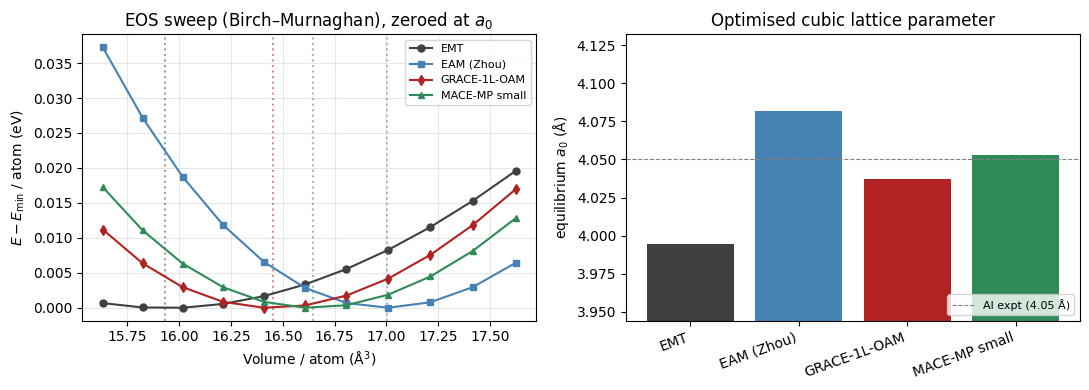

In [5]:
fig, (ax_eos, ax_bar) = plt.subplots(1, 2, figsize=(11, 4))
for r in RUNS:
    d = results[r["label"]]
    n = d["n_atoms_primitive"]
    Vpa = np.asarray(d["eos_volumes"]) / n
    Epa = np.asarray(d["eos_energies"]) / n
    Epa = Epa - Epa.min()  # zero each potential at its own equilibrium
    ax_eos.plot(Vpa, Epa, color=r["color"], marker=r["marker"], markersize=5,
                linewidth=1.5, label=r["label"])
    ax_eos.axvline(d["volume_per_atom"], color=r["color"], linestyle=":", alpha=0.5)

labels = [r["label"] for r in RUNS]
a0s = [results[L]["lattice_a0"] for L in labels]
colors = [r["color"] for r in RUNS]
ax_bar.bar(range(len(labels)), a0s, color=colors)
ax_bar.set_xticks(range(len(labels)))
ax_bar.set_xticklabels(labels, rotation=20, ha="right")
ax_bar.axhline(4.05, color="grey", linestyle="--", linewidth=0.8,
               label="Al expt (4.05 Å)")
ax_bar.set_ylim(min(a0s) - 0.05, max(a0s + [4.05]) + 0.05)
ax_bar.set_ylabel(r"equilibrium $a_0$ (Å)")
ax_bar.set_title("Optimised cubic lattice parameter")
ax_bar.legend(loc="lower right", fontsize=8)
ax_eos.set_xlabel("Volume / atom (Å$^3$)")
ax_eos.set_ylabel(r"$E - E_{\min}$ / atom (eV)")
ax_eos.set_title("EOS sweep (Birch–Murnaghan), zeroed at $a_0$")
ax_eos.legend(fontsize=8)
ax_eos.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## κ(T) overlay


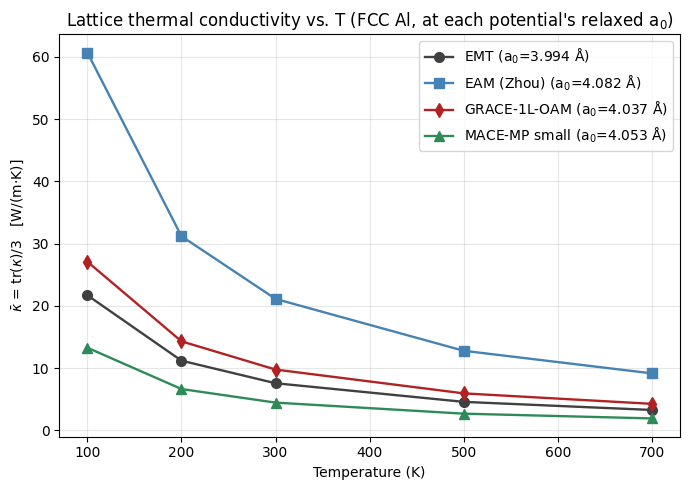

In [6]:
plt.figure(figsize=(7, 5))
for r in RUNS:
    d = results[r["label"]]
    T = np.asarray(d["temperatures"])
    kappa_avg = np.array([np.trace(K) / 3.0 for K in d["kappa"]])
    mask = T > 0  # κ(0)=0 by construction — drop from plot
    plt.plot(
        T[mask], kappa_avg[mask],
        color=r["color"], marker=r["marker"],
        label=f"{r['label']} (a$_0$={d['lattice_a0']:.3f} Å)",
        linewidth=1.7, markersize=7,
    )
plt.xlabel("Temperature (K)")
plt.ylabel(r"$\bar{\kappa}$ = tr($\kappa$)/3   [W/(m$\cdot$K)]")
plt.title("Lattice thermal conductivity vs. T (FCC Al, at each potential's relaxed a$_0$)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


## Phonon band structure + DOS


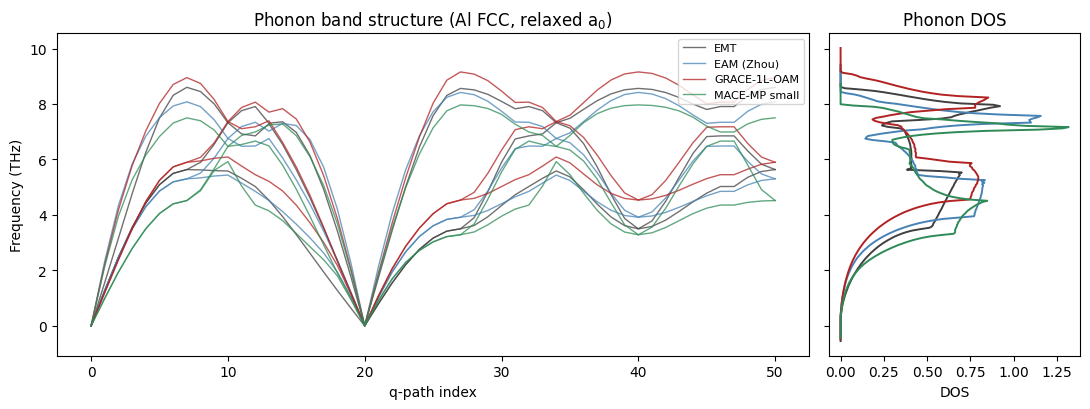

In [7]:
fig, (ax_band, ax_dos) = plt.subplots(
    1, 2, figsize=(11, 4.2),
    gridspec_kw={"width_ratios": [3, 1]}, sharey=True,
)
for r in RUNS:
    d = results[r["label"]]
    bs = d["band_structure"]
    if bs is not None:
        freqs = bs["frequencies"]
        for branch in range(freqs.shape[1]):
            ax_band.plot(
                freqs[:, branch], color=r["color"], linewidth=1.0, alpha=0.75,
                label=r["label"] if branch == 0 else None,
            )
    dos = d["dos"]
    if dos is not None:
        ax_dos.plot(dos["dos"], dos["frequencies"], color=r["color"], linewidth=1.4,
                    label=r["label"])
ax_band.set_xlabel("q-path index")
ax_band.set_ylabel("Frequency (THz)")
ax_band.set_title("Phonon band structure (Al FCC, relaxed a$_0$)")
ax_band.legend(loc="upper right", fontsize=8)
ax_dos.set_xlabel("DOS")
ax_dos.set_title("Phonon DOS")
plt.tight_layout()
plt.show()


## Free energy F(T), entropy S(T), heat capacity Cv(T)

F(T) is plotted relative to each potential's own zero-point energy F(0K) = ZPE so the four curves share a 0-K zero.

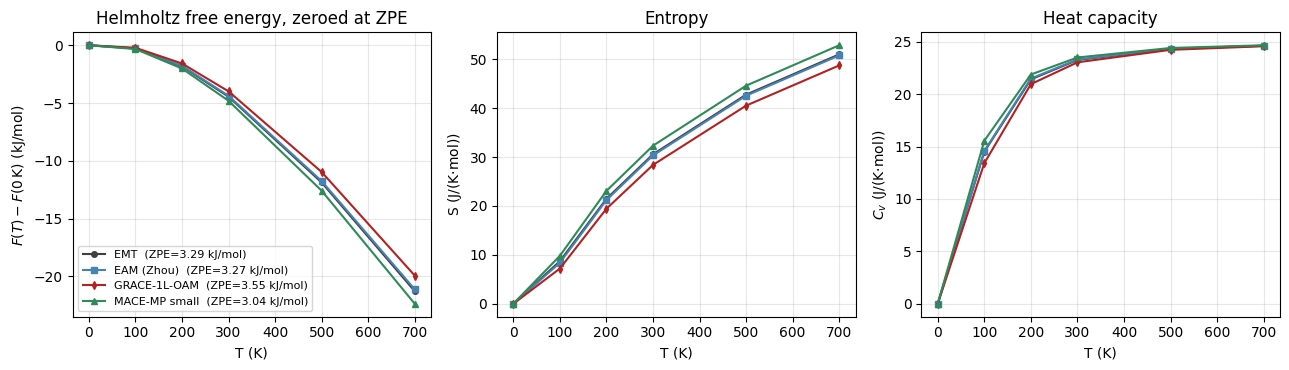

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
for r in RUNS:
    d = results[r["label"]]
    fe = d["free_energy"]
    if fe is None:
        continue
    T = np.asarray(fe["temperatures"])
    i0 = int(np.argmin(np.abs(T - 0.0)))
    zpe = float(fe["F"][i0])
    F_thermal = np.asarray(fe["F"]) - zpe
    axes[0].plot(T, F_thermal, color=r["color"], marker=r["marker"], markersize=4,
                 label=f"{r['label']}  (ZPE={zpe:.2f} kJ/mol)")
    axes[1].plot(T, fe["S"], color=r["color"], marker=r["marker"], markersize=4)
    axes[2].plot(T, fe["Cv"], color=r["color"], marker=r["marker"], markersize=4)
axes[0].set_xlabel("T (K)"); axes[0].set_ylabel(r"$F(T) - F(0\,\mathrm{K})$ (kJ/mol)")
axes[0].set_title("Helmholtz free energy, zeroed at ZPE"); axes[0].legend(fontsize=8)
axes[1].set_xlabel("T (K)"); axes[1].set_ylabel("S (J/(K$\cdot$mol))"); axes[1].set_title("Entropy")
axes[2].set_xlabel("T (K)"); axes[2].set_ylabel(r"$C_v$ (J/(K$\cdot$mol))"); axes[2].set_title("Heat capacity")
for ax in axes:
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
